In [1]:
import numpy as np
import matplotlib.pyplot as plt

pmax = 10
N = 101
p0 = 4
sigp = 0.5
dp = (2 * pmax)/N # spacing between each p

pn = np.arange(-pmax, pmax, dp)

In [2]:
phi_un = np.exp(- ((pn - p0)**2)/(2 * sigp**2))
A = (np.sum(phi_un**2 * dp))**(-1/2)
phi = phi_un * A

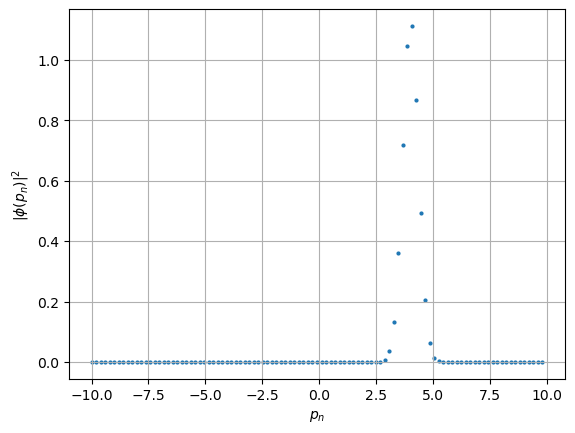

In [3]:
plt.scatter(pn, phi**2, s= 4)
plt.xlabel('$p_n$')
plt.ylabel(r'|$\phi(p_n)$|$^2$')
plt.grid()
plt.show()

In [4]:
dx = 0.1
x_vals = np.arange(-20, 20, dx)
psi_un = np.zeros(len(x_vals), dtype= 'complex_')

for i in range(len(phi)):
    for k in range(len(psi_un)):
        psi_un[k] += (phi[i] * np.exp(1j * pn[i] * x_vals[k]) * dp)

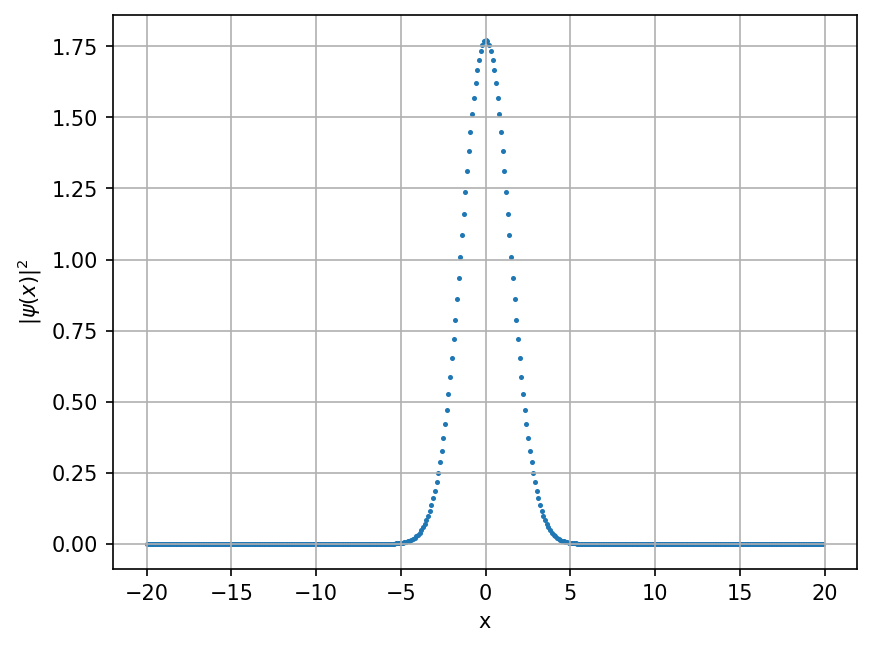

In [5]:
plt.figure(dpi= 150)
plt.scatter(x_vals, abs(psi_un)**2, s= 2)
plt.xlabel('x')
plt.ylabel(r'$|\psi(x)|^2$')
plt.grid()
plt.show()

0.3989422804014357


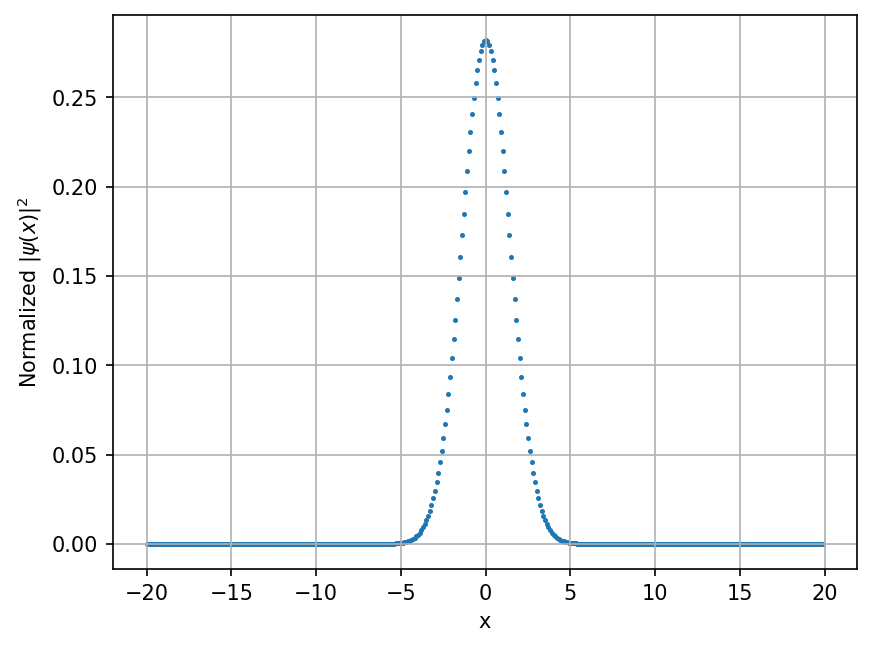

In [6]:
A_psi = (np.sum(abs(psi_un)**2 * dx))**(-1/2)
print(A_psi)
psi = psi_un * A_psi

plt.figure(dpi= 150)
plt.scatter(x_vals, abs(psi)**2, s= 2)
plt.xlabel('x')
plt.ylabel(r'Normalized $|\psi(x)|^2$')
plt.grid()
plt.show()

In [7]:
'''
Calculating ∆x = sqrt(<x^2> - <x>^2)
using
<x> = sum_j x_j |psi(x_j)|^2 dx

and same for ∆p
'''

exp_x = 0
exp_x2 = 0
for i in range(len(psi)):
    exp_x += x_vals[i] * abs(psi[i])**2 * dx
    exp_x2 += x_vals[i]**2 * abs(psi[i])**2 * dx
del_x = np.sqrt(exp_x2 - exp_x**2)

exp_p = 0
exp_p2 = 0
for i in range(len(phi)):
    exp_p += pn[i] * abs(phi[i])**2 * dp
    exp_p2 += pn[i]**2 * abs(phi[i])**2 * dp
del_p = np.sqrt(exp_p2 - exp_p**2)

print('∆x = ' + str(del_x))
print('∆p = ' + str(del_p))
print('∆x∆p = ', str(del_x * del_p))

∆x = 1.4142135623731107
∆p = 0.3535533905932738
∆x∆p =  0.5000000000000056


In [8]:
'''
Now, with phi = B for p within p0 of sigp:

phi(p) = B when abs(p-p0) <= sigp, 0 when abs(p-p0) > sigp
'''

new_phi_un = np.array(abs(pn - p0) <= sigp).astype(int)

B = (np.sum(new_phi_un**2 * dp))**(-1/2)
new_phi = new_phi_un * B

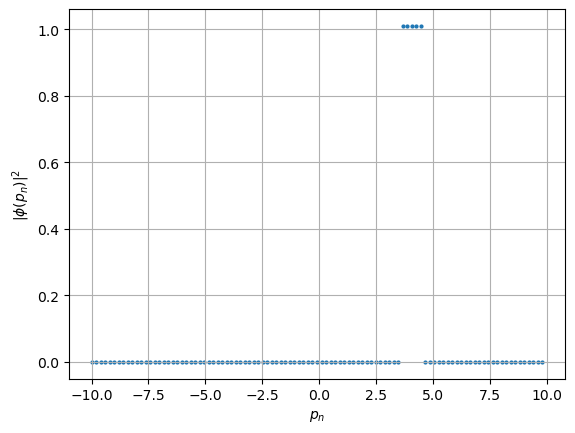

In [9]:
plt.scatter(pn, new_phi**2, s= 4)
plt.xlabel('$p_n$')
plt.ylabel(r'|$\phi(p_n)$|$^2$')
plt.grid()
plt.show()

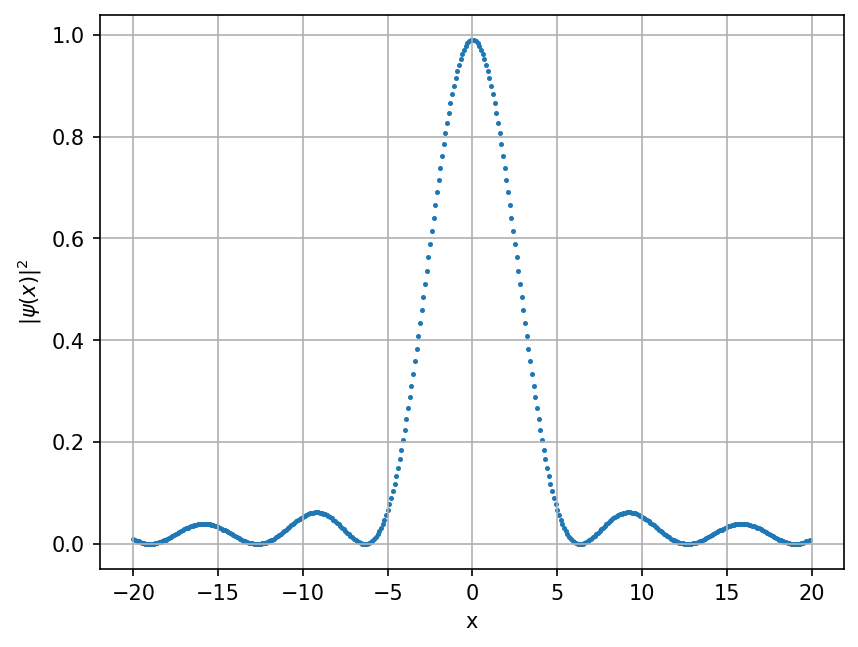

In [10]:
new_psi_un = np.zeros(len(x_vals), dtype= 'complex_')

for i in range(len(new_phi)):
    for k in range(len(new_psi_un)):
        new_psi_un[k] += (new_phi[i] * np.exp(1j * pn[i] * x_vals[k]) * dp)
        
plt.figure(dpi= 150)
plt.scatter(x_vals, abs(new_psi_un)**2, s= 2)
plt.xlabel('x')
plt.ylabel(r'$|\psi(x)|^2$')
plt.grid()
plt.show()

0.39476231354981217


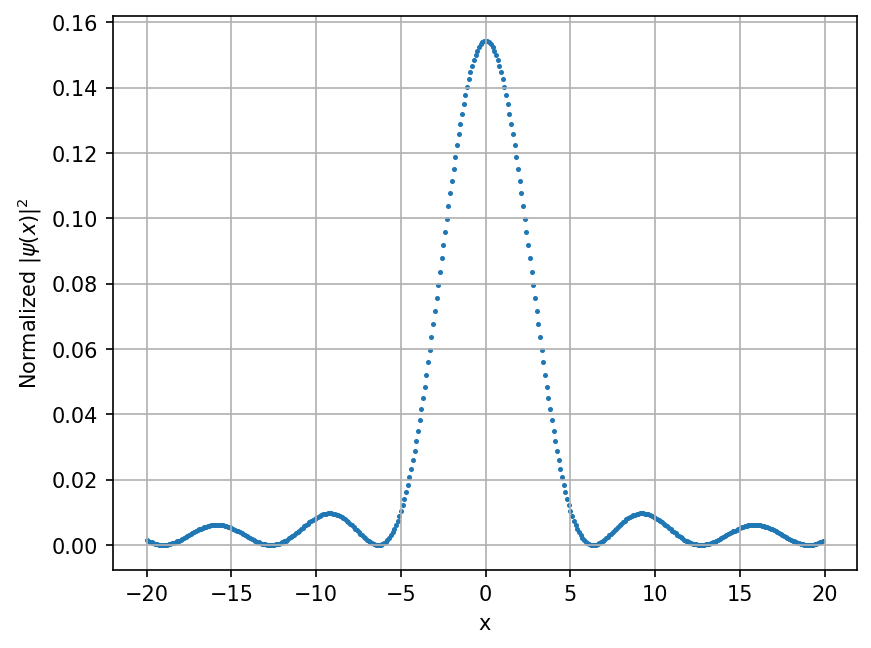

In [11]:
A_new_psi = (np.sum(abs(new_psi_un)**2 * dx))**(-1/2)
print(A_new_psi)
new_psi = new_psi_un * A_new_psi

plt.figure(dpi= 150)
plt.scatter(x_vals, abs(new_psi)**2, s= 2)
plt.xlabel('x')
plt.ylabel(r'Normalized $|\psi(x)|^2$')
plt.grid()
plt.show()

In [12]:
exp_x = 0
exp_x2 = 0
for i in range(len(new_psi)):
    exp_x += x_vals[i] * abs(new_psi[i])**2 * dx
    exp_x2 += x_vals[i]**2 * abs(new_psi[i])**2 * dx
del_x = np.sqrt(exp_x2 - exp_x**2)

exp_p = 0
exp_p2 = 0
for i in range(len(new_phi)):
    exp_p += pn[i] * abs(new_phi[i])**2 * dp
    exp_p2 += pn[i]**2 * abs(new_phi[i])**2 * dp
del_p = np.sqrt(exp_p2 - exp_p**2)

print('∆x = ' + str(del_x))
print('∆p = ' + str(del_p))
print('∆x∆p = ', str(del_x * del_p))

∆x = 4.477596334361302
∆p = 0.28004228957883776
∆x∆p =  1.2539163292843503
